# 　基于MNIST数据集的权重初始值的比较

In [1]:

import sys, os
sys.path.append(os.pardir)
import numpy as np
from typing import Dict, List
import matplotlib.pyplot as plt

from libs.network import NeuralNet
from libs.trainer import Trainer
from libs.util import smooth_curve

# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [2]:
# 加载数据集
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)


# 训练数据集和测试数据集都只取100条(缩短训练时间)
# x_train, t_train = x_train[:100], t_train[:100]
# x_test, t_test = x_test[:100], t_test[:100]

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)


save_file: /Users/simeon/WorkSpace/Projects/Practice/DeepLearnStudy/example/../dataset/data/mnist.pkl
(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


In [3]:
def start_train(optimizer: str='sgd', hidden_size_list: List[int]=[100, 100], epochs: int=5, mini_batch_size: int=100, activation: str="relu", weight_scale: str|float="he") -> List[float]:
    trainer = Trainer(
        network=NeuralNet(input_size=x_train.shape[1], hidden_size_list=hidden_size_list, output_size=t_train.shape[1], activation=activation, weight_scale=weight_scale),
        x_train=x_train,
        t_train=t_train,
        x_test=x_test,
        t_test=t_test,
        optimizer=optimizer,
        # optimizer_param=optimizer_param,
        epochs=epochs,
        mini_batch_size=mini_batch_size,
        verbose=True
    )
    trainer.train()
    return trainer.train_loss_list, trainer.train_acc_list, trainer.test_acc_list

网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:230.26137546001553, train acc:0.09703333333333333, test acc:0.0958
epoch:2, loss:230.01704356891463, train acc:0.11236666666666667, test acc:0.1135
epoch:3, loss:229.43474836784154, train acc:0.11236666666666667, test acc:0.1135
epoch:4, loss:230.64243733186575, train acc:0.11236666666666667, test acc:0.1135
epoch:5, loss:229.88202304551774, train acc:0.13543333333333332, test acc:0.1384
=============== Final Test Accuracy ===============
test acc:0.2166
网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:243.3349344100964, train acc:0.12348333333333333, test acc:0.1296
epoch:2, loss:55.2968611529675, train acc:0.8256166666666667, test acc:0.8304
epoch:3, loss:57.42

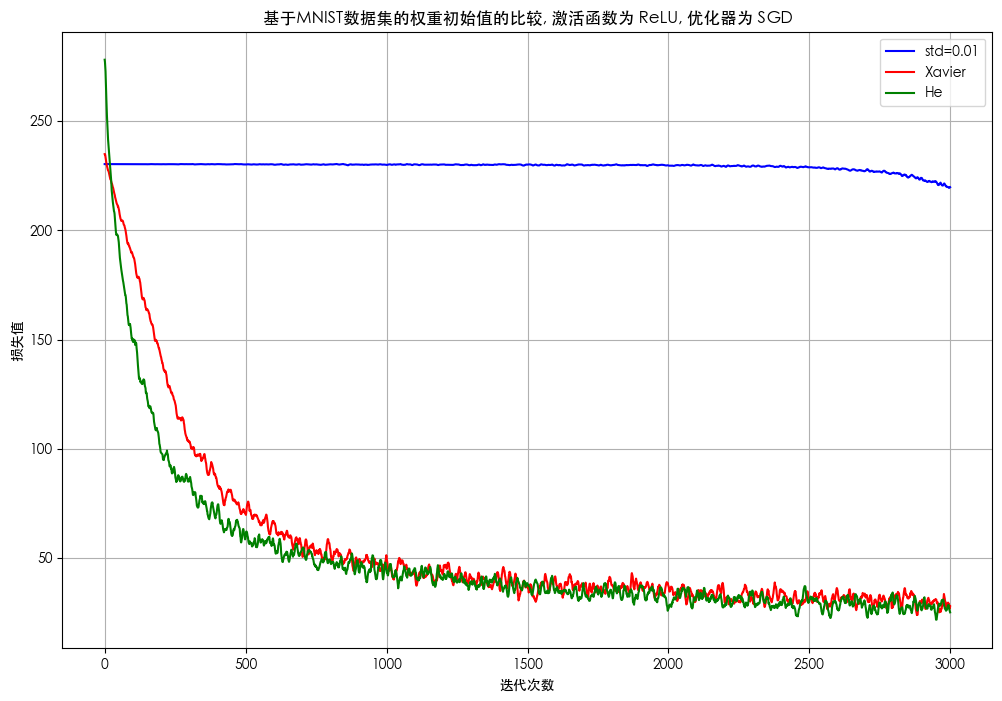

In [4]:

train_loss_relu_std, _, _ = start_train(activation='relu', weight_scale=0.01)
train_loss_relu_xavier, _, _  = start_train(activation='relu', weight_scale='xavier')
train_loss_relu_he, _, _  = start_train(activation='relu', weight_scale='he')
print("\n\n")

plt.figure(figsize=(12, 8))
plt.plot(smooth_curve(train_loss_relu_std), label='std=0.01', color='blue')
plt.plot(smooth_curve(train_loss_relu_xavier), label='Xavier', color='red')
plt.plot(smooth_curve(train_loss_relu_he), label='He', color='green')
plt.title('基于MNIST数据集的权重初始值的比较, 激活函数为 ReLU, 优化器为 SGD')
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.legend()
plt.grid()
plt.show()



网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Sigmoid1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Sigmoid2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:229.63969930834497, train acc:0.09751666666666667, test acc:0.0974
epoch:2, loss:230.46361935561873, train acc:0.10441666666666667, test acc:0.1028
epoch:3, loss:230.57697008400174, train acc:0.11236666666666667, test acc:0.1135
epoch:4, loss:229.5515112368364, train acc:0.11236666666666667, test acc:0.1135
epoch:5, loss:229.91084161490286, train acc:0.10441666666666667, test acc:0.1028
=============== Final Test Accuracy ===============
test acc:0.1135
网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Sigmoid1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Sigmoid2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:255.50122933297257, train acc:0.10441666666666667, test acc:0.1028
epoch:2, loss:225.8615246927639, train acc:0.33516666666666667, test acc:0.3296
epoch

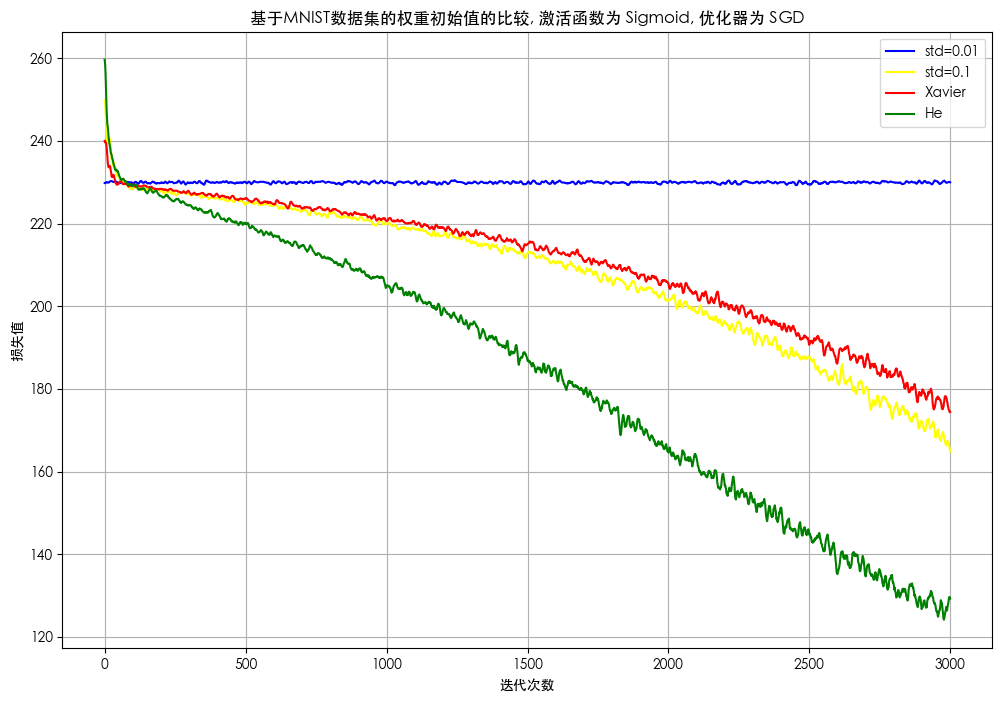

In [7]:

train_loss_std, _, _ = start_train(activation='sigmoid', weight_scale=0.01)
train_loss_std_2, _, _ = start_train(activation='sigmoid', weight_scale=0.1)
train_loss_xavier, _, _  = start_train(activation='sigmoid', weight_scale='xavier')
train_loss_he, _, _  = start_train(activation='sigmoid', weight_scale='he')
print("\n\n")

plt.figure(figsize=(12, 8))
plt.plot(smooth_curve(train_loss_std), label='std=0.01', color='blue')
plt.plot(smooth_curve(train_loss_std_2), label='std=0.1', color='yellow')
plt.plot(smooth_curve(train_loss_xavier), label='Xavier', color='red')
plt.plot(smooth_curve(train_loss_he), label='He', color='green')
plt.title('基于MNIST数据集的权重初始值的比较, 激活函数为 Sigmoid, 优化器为 SGD')
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.legend()
plt.grid()
plt.show()



网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:228.94717800631724, train acc:0.1801, test acc:0.1848
epoch:2, loss:12.009597460819052, train acc:0.9626666666666667, test acc:0.9559
epoch:3, loss:7.255329904738684, train acc:0.9669, test acc:0.9592
epoch:4, loss:1.249268496479948, train acc:0.9736666666666667, test acc:0.9634
epoch:5, loss:4.373692354446116, train acc:0.9742833333333333, test acc:0.9647
=============== Final Test Accuracy ===============
test acc:0.9702
网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:167.36217042294558, train acc:0.35076666666666667, test acc:0.3547
epoch:2, loss:15.501785219288745, train acc:0.95635, test acc:0.9498
epoch:3, loss:13.457803674017143, train acc:0.9693833333333

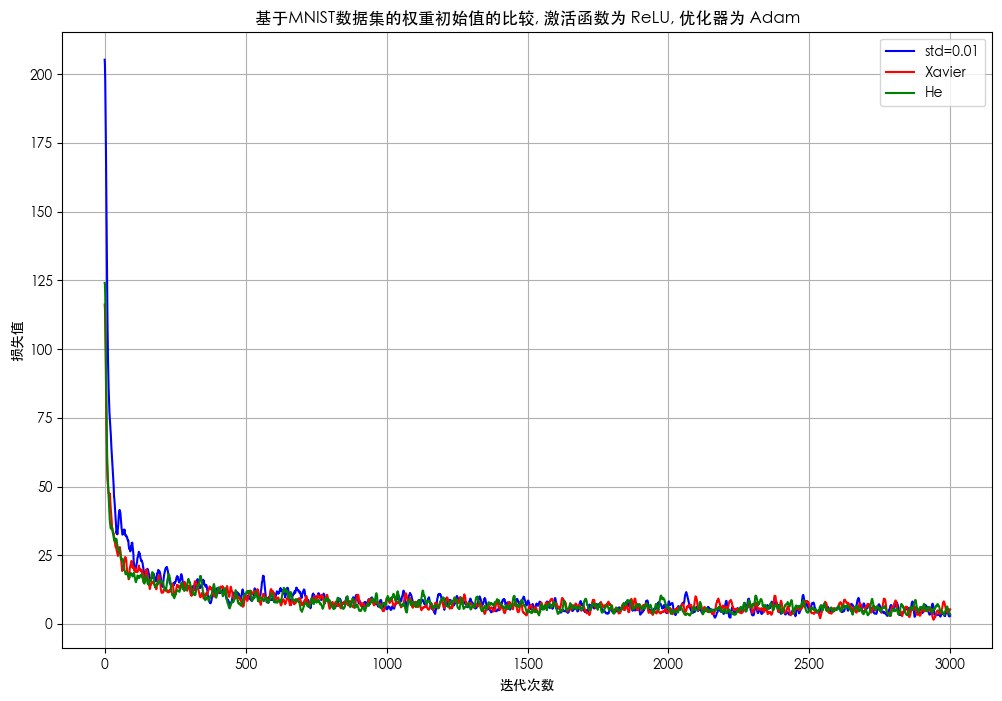

In [6]:
# 使用 Adam 优化器
train_loss_relu_std, _, _ = start_train(optimizer="adam", activation='relu', weight_scale=0.01)
train_loss_relu_xavier, _, _ = start_train(optimizer="adam", activation='relu', weight_scale='xavier')
train_loss_relu_he, _, _ = start_train(optimizer="adam", activation='relu', weight_scale='he')
print("\n\n")

plt.figure(figsize=(12, 8))
plt.plot(smooth_curve(train_loss_relu_std), label='std=0.01', color='blue')
plt.plot(smooth_curve(train_loss_relu_xavier), label='Xavier', color='red')
plt.plot(smooth_curve(train_loss_relu_he), label='He', color='green')
plt.title('基于MNIST数据集的权重初始值的比较, 激活函数为 ReLU, 优化器为 Adam')
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.legend()
plt.grid()
plt.show()